## Model 2: Hierarchical Poisson (season-specific strengths)

**Difference from Model 1:** attack/defense parameters are **per season**, with hierarchical spread `sigma_att`, `sigma_def` (non-centered). Forecast uses strengths from the **last training season** (2024/25).

**Backtest:** same as Model 1 — train through 2024/25, predict table 2025/26 (`2526`).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

from helping_functions import (
    load_matches,
    prepare_stan_data_hierarchical,
    compute_table,
    teams_in_season,
    simulate_seasons_from_hierarchical_draws,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)

In [3]:
matches = load_matches()

TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
LAST_TRAIN_SEASON = "2425"  # last season before forecast 2526

stan_data, team_to_idx, train_teams, season_to_idx = prepare_stan_data_hierarchical(
    matches, TRAIN_SEASONS
)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))
last_season_idx = season_to_idx[LAST_TRAIN_SEASON]

print(f"Training matches: {stan_data['N']}")
print(f"Seasons S={stan_data['S']}, teams T={stan_data['T']}")
print(f"Forecast uses season index {last_season_idx} ({LAST_TRAIN_SEASON})")

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Teams not in training index (att=0, def=0):", new_in_test)

Training matches: 6080
Seasons S=16, teams T=42
Forecast uses season index 16 (2425)


### Fit Stan model

In [4]:
model = CmdStanModel(stan_file="stan/hierarchical.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1500,
    iter_sampling=1500,
    show_progress=True,
)
print(fit.diagnose())

20:57:31 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

21:03:31 - cmdstanpy - INFO - CmdStan done processing.
21:03:31 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hierarchical.stan', line 43, column 4 to column 43)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'hierarchical.stan', line 42, column 4 to column 43)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  mu_att, mu_def, att_raw[1,1], att_raw[2,1], att_raw[3,1], att_raw[4,1], att_raw[5,1], att_raw[6,1], att_raw[7,1], att_raw[8,1], att_raw[9,1], att_raw[10,1], att_raw[11,1], att_raw[12,1], att_raw[13,1], att_raw[14,1], att_raw[15,1], att_raw[16,1], att_raw[1,2], att_raw[2,2], att_raw[3,2], att_raw[4,2], att_raw[5,2], att_raw[6,2], att_raw[7,2], att_raw[8,2], att_raw[9,2], att_raw[10,2], att_raw[11,2], att_raw[12,2], att_raw[13,2], att_raw[14,2], att_raw[15,2], att_raw[16,2], att_raw[1,3], att_raw[2,3], att_raw[3,3], att_raw[4,3], att_raw[5,3], att_raw[6,3], att_raw[7,3], att_raw[8,3], att_raw

In [5]:
fit.summary().loc[["home_adv", "sigma_att", "sigma_def", "lp__"]]

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
home_adv,0.290077,0.000238,0.014514,0.014395,0.266683,0.289832,0.314616,3780.17000,3378.73,1.00067
mu_att,-0.267157,0.152630,0.321321,0.267829,-0.665654,-0.318536,0.425550,7.65689,3000.00,1.48056
mu_def,0.181393,0.201842,0.359968,0.339684,-0.349848,0.116350,0.893987,5.01309,3000.00,2.33145
sigma_att,0.304184,0.000398,0.015562,0.015525,0.278655,0.304053,0.330043,1541.93000,3211.03,1.00039
sigma_def,0.224388,0.000390,0.013187,0.012949,0.203450,0.223868,0.246925,1128.97000,2157.35,1.00269
lp__,-9019.550000,1.312280,41.800700,42.187400,-9090.170000,-9019.240000,-8951.660000,1024.91000,1959.22,1.00192


### Team strengths in the last training season

In [7]:
s_idx = last_season_idx - 1
att_last = fit.stan_variable("att")[:, s_idx, :].mean(axis=0)
def_last = fit.stan_variable("def")[:, s_idx, :].mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(att_last))],
    "att": att_last,
    "def": def_last,
}).sort_values("att", ascending=False)

strengths.head(10)

,team,att,def
20,Liverpool,0.499182,0.137093
22,Man City,0.332740,0.097620
0,Arsenal,0.287967,0.263327
25,Newcastle,0.283755,0.056140
8,Brighton,0.261631,-0.110921
7,Brentford,0.261232,-0.084076
36,Tottenham,0.239244,-0.187585
11,Chelsea,0.226620,0.118847
1,Aston Villa,0.142808,0.004812
6,Bournemouth,0.139161,0.076112


### Example: one team's attack over seasons

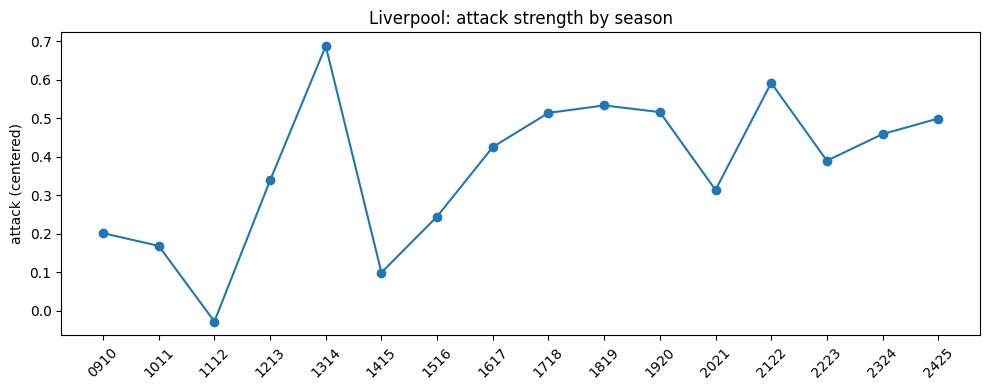

In [8]:
example_team = "Liverpool"
if example_team in team_to_idx:
    j = team_to_idx[example_team] - 1
    att_ts = fit.stan_variable("att")[:, :, j].mean(axis=0)
    seasons = list(season_to_idx.keys())
    plt.figure(figsize=(10, 4))
    plt.plot(seasons, att_ts, marker="o")
    plt.xticks(rotation=45)
    plt.ylabel("attack (centered)")
    plt.title(f"{example_team}: attack strength by season")
    plt.tight_layout()
    plt.show()

### Simulate 2025/26 table & compare to actual

In [9]:
pred_summary = simulate_seasons_from_hierarchical_draws(
    fit, test_teams, team_to_idx, last_season_index=last_season_idx, n_table_sims=500
)
actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_summary.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")

,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,3.0,4.174,67.0,66.970,1,85,2.0
2,Man City,5.0,6.156,62.0,61.746,2,78,3.0
17,Man United,16.0,14.876,43.0,42.912,3,71,13.0
8,Aston Villa,10.0,10.336,52.0,52.486,4,65,6.0
0,Liverpool,2.0,3.356,71.0,70.216,5,60,-3.0
7,Bournemouth,9.0,9.422,54.0,54.542,6,57,3.0
16,Sunderland,14.0,12.994,45.0,46.050,7,54,7.0
6,Brighton,9.0,9.640,54.0,53.644,8,53,1.0
9,Brentford,10.0,9.852,53.0,53.598,9,53,1.0
4,Chelsea,7.0,7.374,59.0,58.814,10,52,-3.0


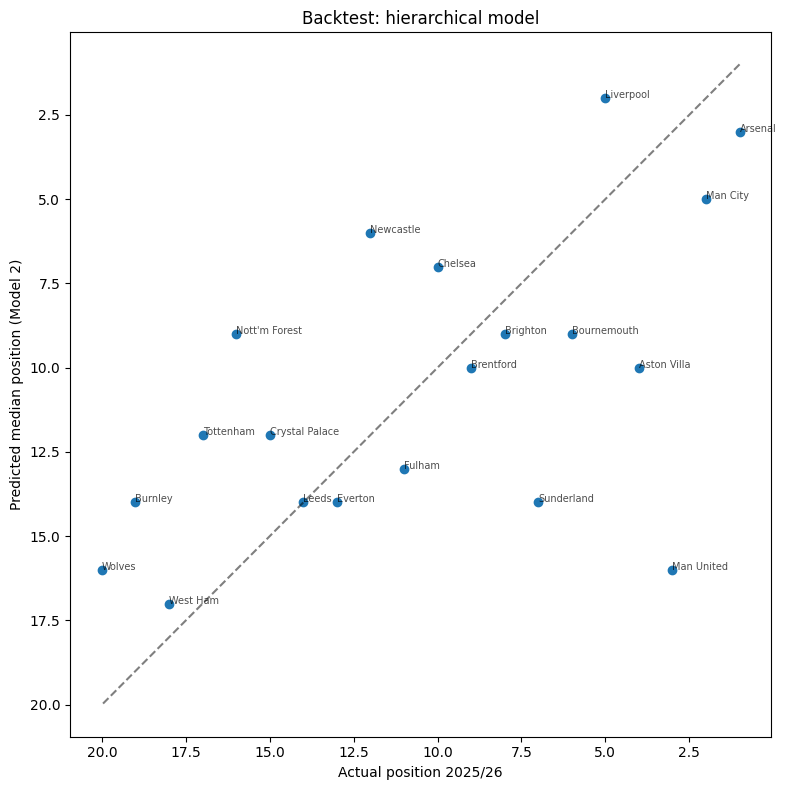

Mean absolute position error: 3.80


In [10]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position (Model 2)")
ax.set_title("Backtest: hierarchical model")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Mean absolute position error: {comparison['pos_error'].abs().mean():.2f}")

### Posterior predictive check (pooled goals)

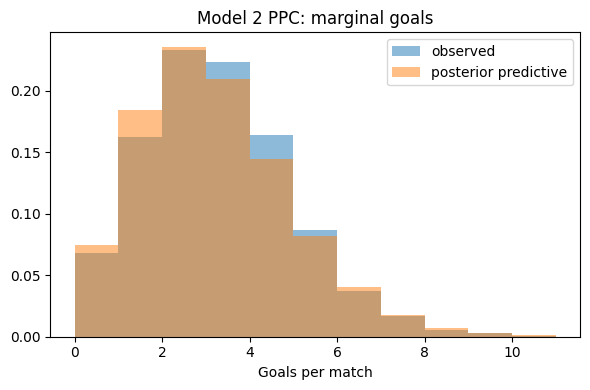

In [11]:
train = matches[matches["season"].isin(TRAIN_SEASONS)]
obs_goals = (train["FTHG"] + train["FTAG"]).values

att = fit.stan_variable("att")
def_ = fit.stan_variable("def")
ha = fit.stan_variable("home_adv")
rng = np.random.default_rng(1)

home_idx = stan_data["home"] - 1
away_idx = stan_data["away"] - 1
season_idx = stan_data["season"] - 1

rep_pooled = []
for _ in range(80):
    d = rng.integers(0, att.shape[0])
    for si, hi, ai in zip(season_idx, home_idx, away_idx):
        lh = np.exp(ha[d] + att[d, si, hi] - def_[d, si, ai])
        la = np.exp(att[d, si, ai] - def_[d, si, hi])
        rep_pooled.append(rng.poisson(lh) + rng.poisson(la))

rep_pooled = np.array(rep_pooled)
bins = range(0, 12)

plt.figure(figsize=(6, 4))
plt.hist(obs_goals, bins=bins, density=True, alpha=0.5, label="observed")
plt.hist(rep_pooled, bins=bins, density=True, alpha=0.5, label="posterior predictive")
plt.xlabel("Goals per match")
plt.legend()
plt.title("Model 2 PPC: marginal goals")
plt.tight_layout()
plt.show()

### WAIC / LOO (for comparison with Model 1)

Run the same cell in `02_model1_poisson.ipynb` after fitting Model 1, or load saved `log_lik` here.

In [13]:
log_lik = fit.stan_variable("log_lik")  # (draws, N)
idata = az.from_dict(log_likelihood={"match": log_lik})
print(az.waic(idata))
print(az.loo(idata))

/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(
/usr/local/lib/python3.11/site-packages/arviz/stats/stats.py:1683: UserWarning: The point-wise WAIC is the same with the sum WAIC, please double check
            the Observed RV in your model to make sure it returns element-wise logp.
            
  warnings.warn(


Computed from 36480000 posterior samples and 1.0 observations log-likelihood matrix.

          Estimate       SE
elpd_waic    -3.51     0.00
p_waic        0.90        -

There has been a warning during the calculation. Please check the results.


TypeError: Must be able to extract a posterior group from data.